# To analyze student data and build a classification model that predicts depression while identifying key contributing factors such as sleep duration and stress level.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("DATASET/clean_student_data.csv")

## QCUIK information of the data

In [3]:
data.head(10)

,Student_ID,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media,Physical_Activity,Stress_Level,Depression
0,1001,24,Male,Medical,5.71,7.5,4.7,1.6,0.1,6.7,False
1,1002,21,Female,Medical,7.63,6.7,1.4,0.6,1.9,2.7,False
2,1003,22,Male,Arts,7.66,5.5,3.4,1.5,1.8,5.2,False
3,1004,24,Male,Engineering,8.05,8.1,1.9,3.7,1.9,3.6,False
4,1005,20,Female,Medical,8.40,7.4,1.4,2.8,2.0,3.3,False
5,1006,25,Male,Medical,9.40,4.8,7.9,5.4,0.3,10.0,True
6,1007,22,Female,Science,7.57,8.6,3.3,5.0,0.8,6.2,False
7,1008,22,Female,Medical,6.79,8.1,6.7,2.4,1.5,5.4,False
8,1009,24,Female,Medical,8.68,8.7,2.8,1.9,1.4,3.2,False
9,1010,19,Male,Science,6.58,7.6,5.8,2.6,0.3,7.4,False


## Understading the datatypes of the data shape and size of the data using info 

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Student_ID         200 non-null    int64  
 1   Age                200 non-null    int64  
 2   Gender             200 non-null    object 
 3   Department         200 non-null    object 
 4   CGPA               200 non-null    float64
 5   Sleep_Duration     200 non-null    float64
 6   Study_Hours        200 non-null    float64
 7   Social_Media       200 non-null    float64
 8   Physical_Activity  200 non-null    float64
 9   Stress_Level       200 non-null    float64
 10  Depression         200 non-null    bool   
dtypes: bool(1), float64(6), int64(2), object(2)
memory usage: 15.9+ KB


## Checking the size of the data 

In [5]:
data.size

2200

## Cheking the outliers in sleep_duration

<Axes: xlabel='Sleep_Duration'>

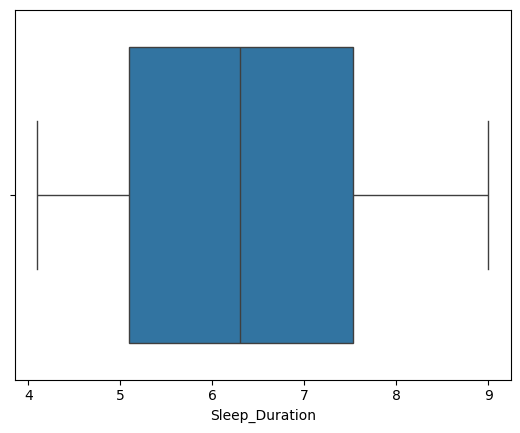

In [6]:
sns.boxplot(data=data, x="Sleep_Duration")

## Cheking the outliers in CGPA

<Axes: xlabel='CGPA'>

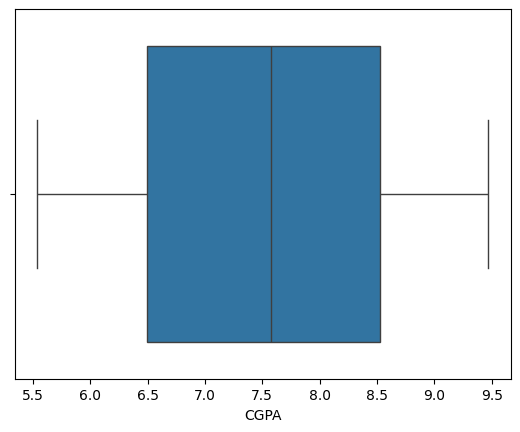

In [7]:
sns.boxplot(data=data, x="CGPA")

## Cheking the outliers in Social media

<Axes: xlabel='Social_Media'>

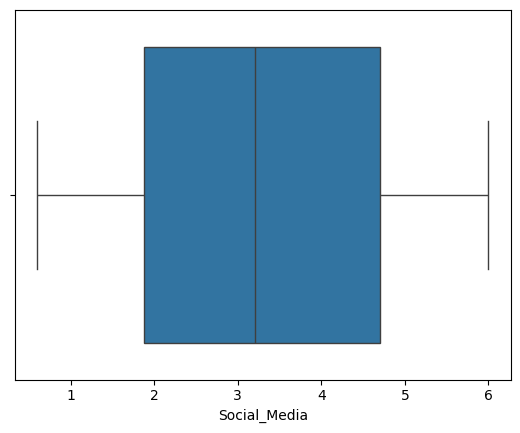

In [8]:
sns.boxplot(data=data, x="Social_Media")

## Cheking the outliers in physical_Acitivity

<Axes: xlabel='Physical_Activity'>

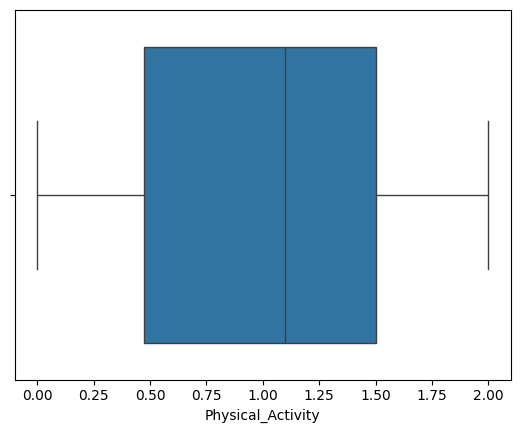

In [9]:
sns.boxplot(data=data, x="Physical_Activity")

## Cheking the outliers in Stress level

<Axes: xlabel='Stress_Level'>

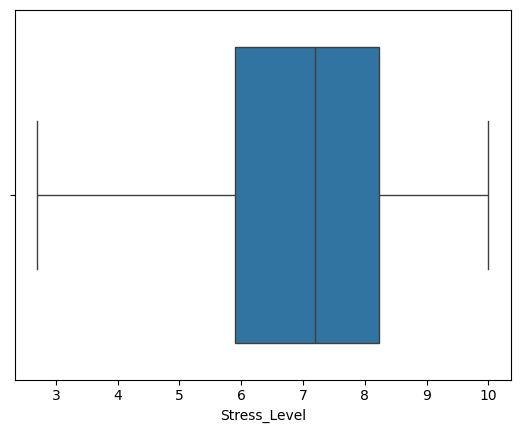

In [10]:
sns.boxplot(data=data, x="Stress_Level")

## Cheking the unique departmnets

In [11]:
data["Department"].value_counts()

Department
Medical        58
Science        53
Engineering    47
Arts           42
Name: count, dtype: int64

## Data Encoding 

In [12]:
data["Department"] = data["Department"].replace({"Medical" :0,"Science":1,"Engineering":2,"Arts":3})

C:\Users\HP\AppData\Local\Temp\ipykernel_6436\3031188844.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data["Department"] = data["Department"].replace({"Medical" :0,"Science":1,"Engineering":2,"Arts":3})


In [13]:
data["Department"].unique()

array([0, 3, 2, 1])

In [14]:
data["Gender"].unique()

array(['Male', 'Female'], dtype=object)

In [15]:
data["Gender"]= data["Gender"].replace({"Male" :0, "Female":1})

C:\Users\HP\AppData\Local\Temp\ipykernel_6436\3694101494.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data["Gender"]= data["Gender"].replace({"Male" :0, "Female":1})


In [16]:
data["Depression"] = data["Depression"].replace({"False":0, "True":1})

## Checking the correlation

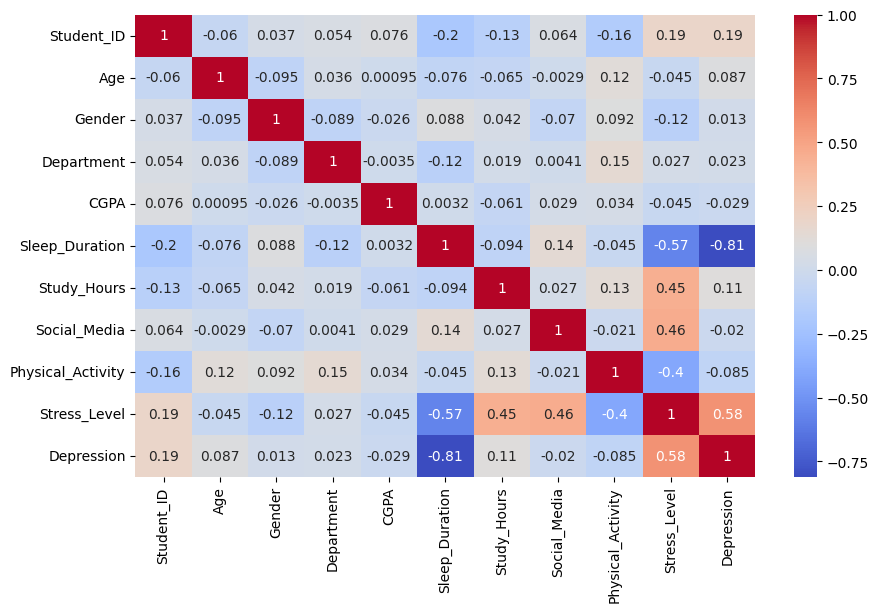

In [17]:
plt.figure(figsize=(10,6))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm")
plt.show()

## Feature Selaction

In [18]:
data.drop(columns=["Student_ID"], inplace=True)

In [19]:
data.columns

Index(['Age', 'Gender', 'Department', 'CGPA', 'Sleep_Duration', 'Study_Hours',
       'Social_Media', 'Physical_Activity', 'Stress_Level', 'Depression'],
      dtype='object')

In [20]:
data.drop(columns=["Age","Gender","Department","CGPA"], inplace=True)

In [21]:
data.columns

Index(['Sleep_Duration', 'Study_Hours', 'Social_Media', 'Physical_Activity',
       'Stress_Level', 'Depression'],
      dtype='object')

## Quck statstical info data

In [22]:
data.describe() # data deviation is perfect no neet to scalling 

,Sleep_Duration,Study_Hours,Social_Media,Physical_Activity,Stress_Level
count,200.000000,200.00000,200.000000,200.000000,200.000000
mean,6.391000,4.43600,3.262000,1.017000,7.063000
std,1.428574,2.02812,1.618255,0.597744,1.772694
min,4.100000,1.00000,0.600000,0.000000,2.700000
25%,5.100000,2.60000,1.875000,0.475000,5.900000
50%,6.300000,4.40000,3.200000,1.100000,7.200000
75%,7.525000,6.20000,4.700000,1.500000,8.225000
max,9.000000,8.00000,6.000000,2.000000,10.000000


In [43]:
x = data.drop("Depression", axis=1)
y = data["Depression"]

In [44]:
from sklearn.model_selection import train_test_split

## Spliting the data into train and test

In [45]:
X_train, X_test, Y_train, Y_test = train_test_split(x, y, test_size=0.3, random_state=45)

In [46]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()

## Cross validation 

In [54]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(dt, x, y, cv=5)
print("CV Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean()

CV Scores: [1. 1. 1. 1. 1.]
Mean CV Accuracy: 1.0


## Training the data 

In [55]:
dt.fit(X_train, Y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

## Ploting the tree 

[Text(0.6, 0.8333333333333334, 'Sleep_Duration <= 5.95\ngini = 0.485\nsamples = 140\nvalue = [82.0, 58.0]'),
 Text(0.4, 0.5, 'Stress_Level <= 6.05\ngini = 0.094\nsamples = 61\nvalue = [3, 58]'),
 Text(0.5, 0.6666666666666667, 'True  '),
 Text(0.2, 0.16666666666666666, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.6, 0.16666666666666666, 'gini = 0.0\nsamples = 58\nvalue = [0, 58]'),
 Text(0.8, 0.5, 'gini = 0.0\nsamples = 79\nvalue = [79, 0]'),
 Text(0.7, 0.6666666666666667, '  False')]

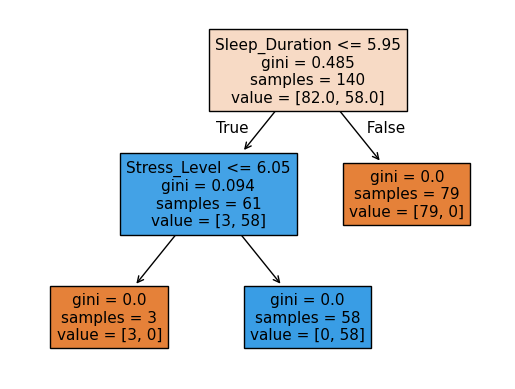

In [56]:
from sklearn.tree import plot_tree
plot_tree(dt,filled=True, feature_names=x.columns)

## predictions for testing data

In [57]:
test_predict = dt.predict(X_test)

## Predictions for training data

In [58]:
train_predict = dt.predict(X_train)

In [59]:
from sklearn.metrics import classification_report , confusion_matrix , accuracy_score

## Checking the training accuracy

In [60]:
accuracy_score(Y_train, train_predict)

1.0

## Checking the testing accuracy

In [53]:
accuracy_score(Y_test, test_predict)

1.0

## Re-train → re-test → re-check confusion matrix.

In [37]:
dt = DecisionTreeClassifier(  
    max_depth=2,
    min_samples_leaf=5,
    random_state=42
)

CV Scores: [1. 1. 1. 1. 1.]
Mean CV Accuracy: 1.0


## Checking the confusion matrix

In [39]:
print(confusion_matrix(Y_test, test_predict))


[[40  0]
 [ 0 20]]
